**INTELIGÊNCIA ARTIFICIAL **

Prof. Marcones Cleber

## Métricas de Desempenho com Regressão Logistíca e k-NN

In [65]:
# Importando as bibliotecas necessárias
# Métricas usadas para comparações
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay,
    confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
)

# Importando os modelos que serão utilizados
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Plot dos gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Tratamento de dados
import pandas as pd
from collections import Counter


Métrica de Desempenho de Classificação

Vamos usar dados do https://www.openml.org/d/37

Fazendo a análise exploratória de Dados:

In [66]:
# Vamos carregar dados publicos
diabetes = fetch_openml(data_id=37)

In [67]:
# checando a dimensao dos dados recebidos
diabetes.data.shape

(768, 8)

In [68]:
# nome das features disponiveis
diabetes.feature_names

['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

In [69]:
# Separando as colunas de features para analisar esses dados
dados = pd.DataFrame(data=diabetes.data, columns = diabetes.feature_names)

In [70]:
dados.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [71]:
dados.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'insu'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

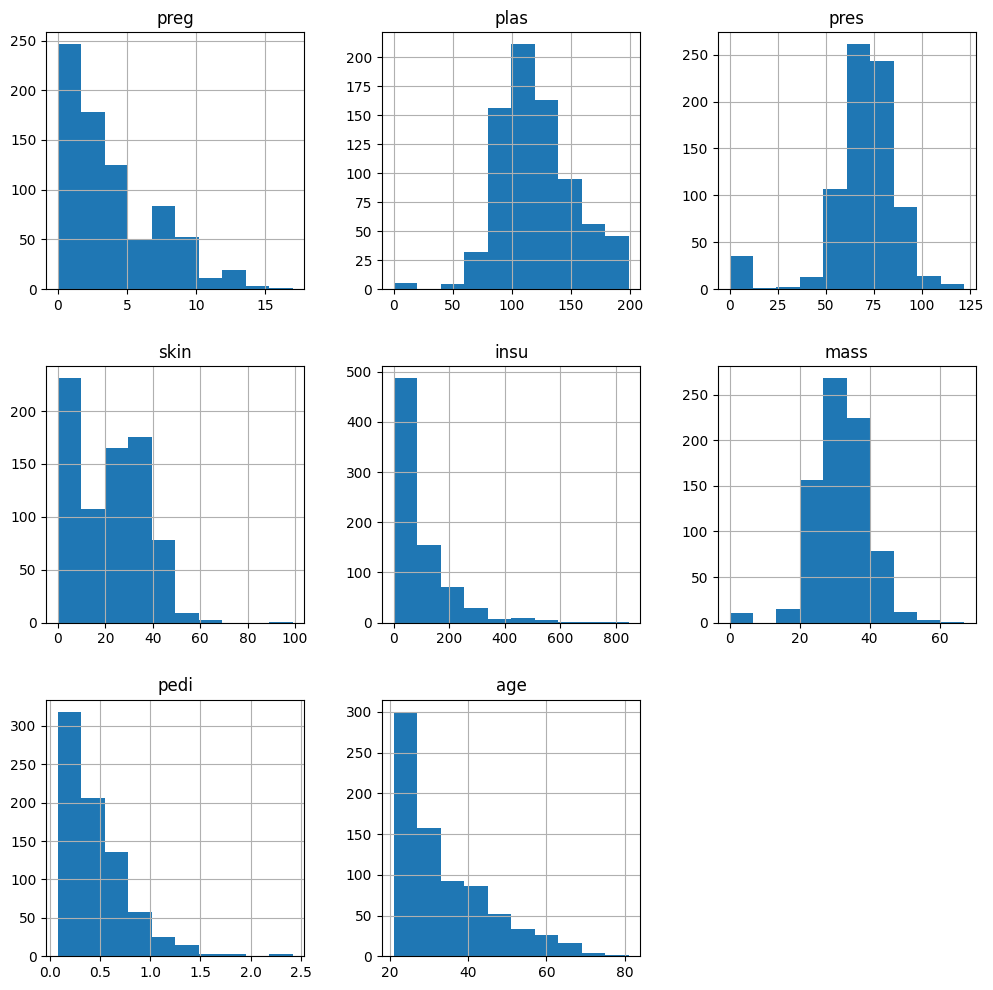

In [72]:
dados.hist(figsize=(12,12))

Alguns dos nossos dados não estão seguindo uma distribuição gaussiana. Assim, vamos ter que normalizar os nossos dados

# Criando o Modelo de Regressão Logistica


In [73]:
# Vendo a distribuição das classes
Counter(diabetes.target)

Counter({'tested_positive': 268, 'tested_negative': 500})

In [74]:
# Dividindo os dados no conjunto de teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

# Aplicando a padronizacao
# levantando os minimos e maximos
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Fazendo a regressao logistica
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred = log_reg.predict(x_test_scaled)

In [75]:
# Checando 20 primeiras saidas das previsoes
y_pred[:20]

array(['tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_positive',
       'tested_positive', 'tested_negative', 'tested_positive',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_positive', 'tested_negative'], dtype=object)

In [76]:
# Checando as 20 primeiras saidas dos labels
y_test[:20]

,class
668,tested_negative
324,tested_negative
624,tested_negative
690,tested_negative
473,tested_negative
204,tested_negative
97,tested_negative
336,tested_negative
568,tested_negative
148,tested_negative


In [77]:
# Comparando usando o DataFrame
pd.DataFrame({'pred': y_pred, 'resp': y_test})

,pred,resp
668,tested_negative,tested_negative
324,tested_negative,tested_negative
624,tested_negative,tested_negative
690,tested_negative,tested_negative
473,tested_negative,tested_negative
...,...,...
355,tested_positive,tested_positive
534,tested_negative,tested_negative
344,tested_negative,tested_negative
296,tested_negative,tested_positive


A boa notícia é que não precisamos comparar cada um dos dados manualmente. O próprio sklearn possui as métricas que aprendemos anteriormente.

# Avaliando as métricas do nosso modelo

Primeiro vamos analisar pelas classes se há discrepância na classificação:

In [78]:
# Vendo a distribuição das classes
Counter(y_test)

Counter({'tested_negative': 99, 'tested_positive': 55})

In [79]:
# Vendo a distribuição das classes
Counter(y_pred)

Counter({'tested_negative': 107, 'tested_positive': 47})

Numa primeira análise, sem as métricas das aula, parece muito promissor o resultado obtido

Vamos checar a matriz de confusao:

In [80]:
cm = confusion_matrix(y_test, y_pred, labels = ['tested_positive','tested_negative'])
cm

array([[32, 23],
       [15, 84]])

<Figure size 1500x500 with 0 Axes>

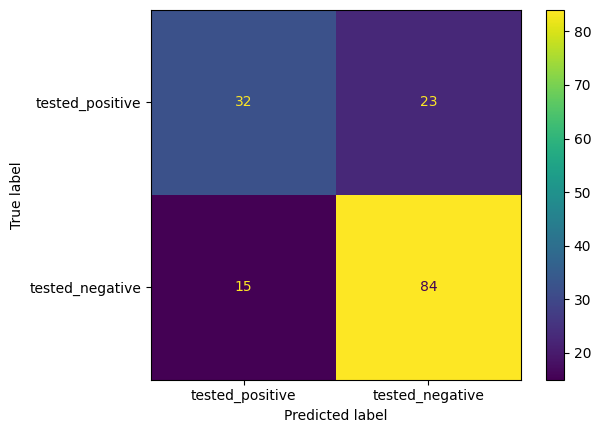

In [81]:
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['tested_positive','tested_negative'])
disp.plot(values_format='d')



Começando com a precisão:

$precisao = \frac{TP}{TP+FP}$

In [82]:
# Calculando a precisão para o "tested negative"
precision_score(y_test, y_pred, pos_label='tested_positive')

0.6808510638297872

In [83]:
# Precisao para o nosso modelo
precisao = 45/(45+24)
precisao

0.6521739130434783

Calculando a revocação:

$revocacao = \frac{TP}{TP+FN}$

In [84]:
recall_score(y_test, y_pred, pos_label='tested_positive')

0.5818181818181818

In [85]:
# revocacao para o nosso modelo
revocacao = 45/(45+35)
revocacao

0.5625

Calculando o f1 score:

$F_{1} = 2\times\frac{precisao \times revocacao}{precisao + revocacao}$

In [86]:
f1_score(y_test, y_pred, pos_label='tested_positive')

0.6274509803921569

In [87]:
# f1 score para o nosso modelo
f1 = 2*(precisao*revocacao)/(precisao+revocacao)
f1

0.6040268456375839

Calculando a acurácia:

$acuracia = \frac{TP+TN}{TP+TN+FP+FN}$

In [88]:
# Acuracia p ara o nosso modelo
accuracy_score(y_test, y_pred)

0.7532467532467533

In [89]:
# Comparando com o que vimos em aula
acuracia = (127+45)/(127+24+35+45)
acuracia

0.7445887445887446

**Exercício 1)** Recalcular as métricas de acurácia, revocação e f1 score do estudo acima considerando que a classe positiva dos nossos estudos é o 'tested_negative'

(0.7850467289719626,
 0.8484848484848485,
 0.8155339805825242,
 0.7532467532467533)

<Figure size 1500x500 with 0 Axes>

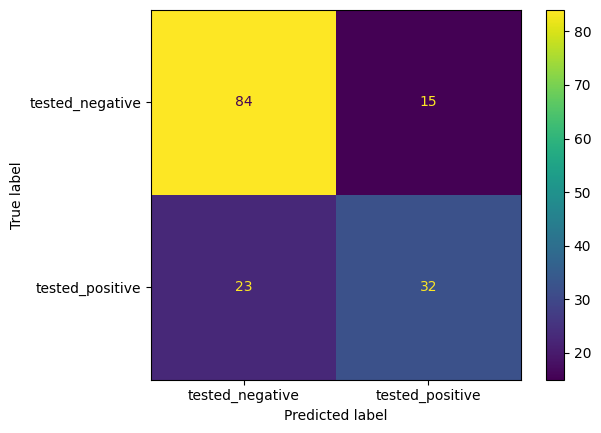

In [90]:
# Gerando a matriz de confusao
cm = confusion_matrix(y_test, y_pred, labels = ['tested_negative','tested_positive'])

## Coloque seu código aqui
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['tested_negative','tested_positive'])
disp.plot(values_format='d')

(precision_score(y_test, y_pred, pos_label='tested_negative'),
recall_score(y_test, y_pred, pos_label='tested_negative'),
f1_score(y_test, y_pred, pos_label='tested_negative'),
accuracy_score(y_test, y_pred))



In [91]:
# outra forma de checar as métricas de ambas as classes:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

tested_negative       0.79      0.85      0.82        99
tested_positive       0.68      0.58      0.63        55

       accuracy                           0.75       154
      macro avg       0.73      0.72      0.72       154
   weighted avg       0.75      0.75      0.75       154



A partir dos resultados, o que podemos concluir dos resultados do nosso modelo?

Vamos agora checar a curva ROC do nosso modelo:

In [92]:
y_score = log_reg.predict_proba(x_test_scaled)
y_score.shape

(154, 2)

In [93]:
# Primeiro vamos levar o valor das probabilidades, isto é, os valores sem aplicarmos a classificacao.
y_score = log_reg.predict_proba(x_test_scaled)[:,1]
# Calculando o valor da AUC para o nosso modelo
roc_auc = roc_auc_score(y_test,y_score)
roc_auc

np.float64(0.8128558310376491)

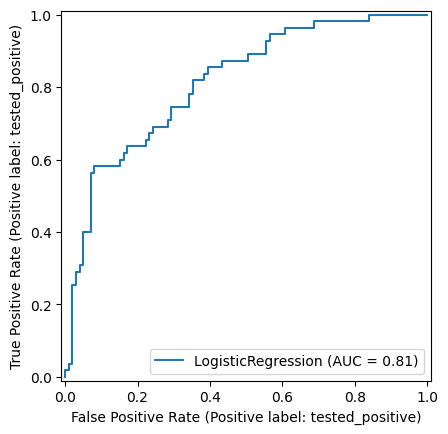

In [94]:
# !pip install scikit-learn -U  # Execute no terminal ou notebook para atualizar scikit-learn, se necessário

import matplotlib.pyplot as plt  # Importando matplotlib para plotagem
from sklearn.metrics import RocCurveDisplay  # Importando RocCurveDisplay

# ... (seu código existente) ...

# Plotando a curva ROC
RocCurveDisplay.from_estimator(log_reg, x_test_scaled, y_test)
plt.show()  # Exibindo o gráfico


## Criando o modelo com o k-NN

Gerando o modelo com o k-NN

In [95]:
# Dividindo os dados no conjunto de teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

# Aplicando a padronizacao
# calculando o maximos e o minimo
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Fazendo o k-NN
# n_neighbors é o valor da quantidade de vizinhos que será considerada
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_knn = knn_clf.predict(x_test_scaled)

Checando a matriz de confusão obtida com o k-NN

In [96]:
cm_knn = confusion_matrix(y_test, y_pred_knn, labels = ['tested_positive','tested_negative'])
cm_knn

array([[29, 26],
       [23, 76]])

<Figure size 1500x500 with 0 Axes>

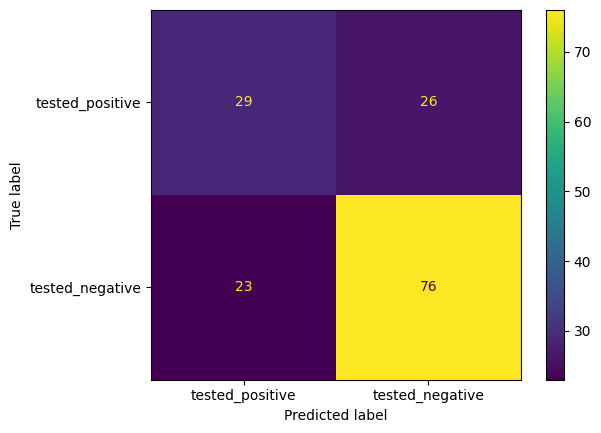

In [97]:
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_knn, display_labels=['tested_positive','tested_negative'])
disp.plot(values_format='d')

In [98]:
# Calculando a precisão para o "tested_positive"
precision_score(y_test, y_pred_knn, pos_label='tested_positive')

0.5576923076923077

In [99]:
recall_score(y_test, y_pred_knn, pos_label='tested_positive')

0.5272727272727272

In [100]:
f1_score(y_test, y_pred_knn, pos_label='tested_positive')

0.5420560747663551

In [101]:
# Acuracia para o nosso modelo
accuracy_score(y_test, y_pred_knn)

0.6818181818181818

In [102]:
# Primeiro vamos levar o valor das probabilidades, isto é, os valores sem aplicarmos a classificacao.
y_score_knn = knn_clf.predict_proba(x_test_scaled)[:,1]
# Calculando o valor da AUC para o nosso modelo
roc_auc_knn = roc_auc_score(y_test,y_score_knn)
roc_auc_knn

np.float64(0.7486685032139577)

In [103]:
print(classification_report(y_test, y_pred_knn))

                 precision    recall  f1-score   support

tested_negative       0.75      0.77      0.76        99
tested_positive       0.56      0.53      0.54        55

       accuracy                           0.68       154
      macro avg       0.65      0.65      0.65       154
   weighted avg       0.68      0.68      0.68       154



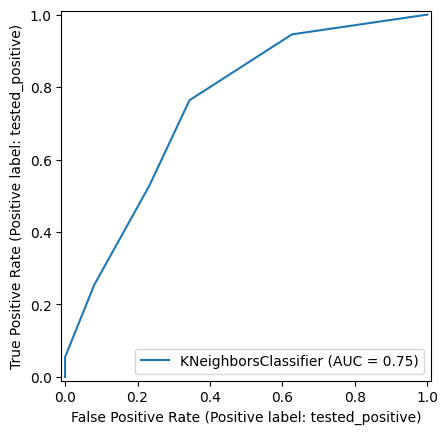

In [104]:
from sklearn.metrics import RocCurveDisplay

# Supondo que 'knn_clf', 'x_test_scaled' e 'y_test' já estejam definidos
RocCurveDisplay.from_estimator(knn_clf, x_test_scaled, y_test)

# Exibindo o gráfico da curva ROC
plt.show()


Comparando as duas curvas ROC (Regressão Logística versus k-NN):

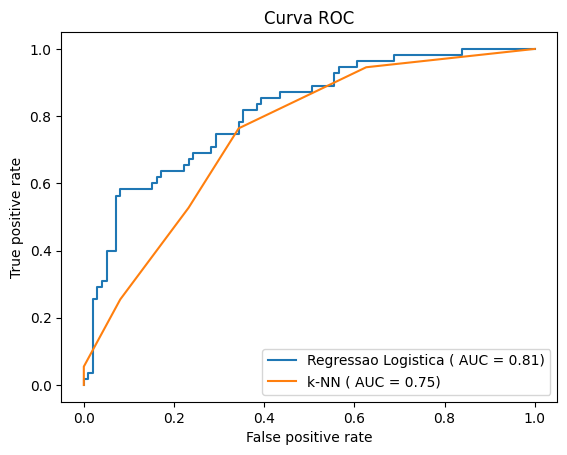

In [105]:
# Para plotar a curva ROC com ambos modelos vamos usar o RocCurveDisplay

# cuidado com o pos_label, se você colocar da classe negativa a curva ROC vai ficar invertida. Sempre analisar visualmente a imagem e o AUC
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_score, pos_label='tested_positive')
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_score_knn, pos_label='tested_positive')

# plotando o grafico
plt.figure()
plt.plot(fpr_log, tpr_log, label='%s ( AUC = %0.2f)' % ('Regressao Logistica', roc_auc))
plt.plot(fpr_knn, tpr_knn, label='%s ( AUC = %0.2f)' % ('k-NN', roc_auc_knn))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Curva ROC')
plt.legend(loc='best')
plt.show()

#Treinando o modelo de árvore de decisão

In [106]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [110]:
#treindando o modelo de árvore
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

# Aplicando a padronizacao
# calculando o maximos e o minimo
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

**Exercício 2)** Refazer o modelo de k-NN considerando k=15. Calcular as métricas de acurácia, revocação e f1 score do estudo acima considerando que a classe positiva dos nossos estudos é o 'tested_positive'. Houve alguma melhora nos resultados?

In [111]:
# Teste e treino para o novo knn
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

# Padronização
scaler_knn = MinMaxScaler().fit(X_train_knn)
# Mudando a escala dos dados
x_train_scaled_knn = scaler.transform(X_train_knn)
x_test_scaled_knn = scaler.transform(X_test_knn)

# Fazendo o k-NN
# n_neighbors é o valor da quantidade de vizinhos que será considerada
knn_clf_2 = KNeighborsClassifier(n_neighbors=15, metric='minkowski')
knn_clf_2.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_knn_2 = knn_clf_2.predict(x_test_scaled_knn)


In [112]:
cm_knn_2 = confusion_matrix(y_test_knn, y_pred_knn_2, labels = ['tested_positive','tested_negative'])
cm_knn_2

array([[30, 25],
       [16, 83]])

<Figure size 1500x500 with 0 Axes>

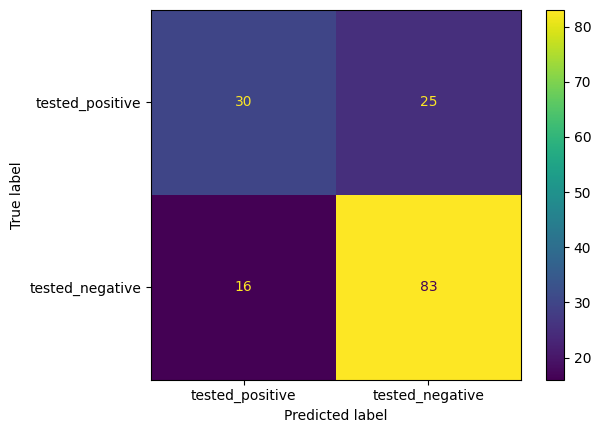

In [113]:
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_knn_2, display_labels=['tested_positive','tested_negative'])
disp.plot(values_format='d')

In [114]:
precisao_knn = precision_score(y_test_knn, y_pred_knn_2, pos_label='tested_positive')
revocacao_knn = recall_score(y_test_knn, y_pred_knn_2, pos_label='tested_positive')
f1_knn = f1_score(y_test_knn, y_pred_knn_2, pos_label='tested_positive')
acuaria_knn = accuracy_score(y_test_knn, y_pred_knn_2)

print(f"Precisão: {precisao_knn}")
print(f"Revocação: {revocacao_knn}")
print(f"F1 Score: {f1_knn}")
print(f"Acurácia: {acuaria_knn}")

Precisão: 0.6521739130434783
Revocação: 0.5454545454545454
F1 Score: 0.594059405940594
Acurácia: 0.7337662337662337


In [115]:
# Primeiro vamos levar o valor das probabilidades, isto é, os valores sem aplicarmos a classificacao.
y_score_knn_2 = knn_clf.predict_proba(x_test_scaled_knn)[:,1]
# Calculando o valor da AUC para o nosso modelo
roc_auc_knn = roc_auc_score(y_test_knn,y_score_knn_2)
roc_auc_knn

np.float64(0.7486685032139577)

In [116]:
print(classification_report(y_test_knn, y_pred_knn_2))

                 precision    recall  f1-score   support

tested_negative       0.77      0.84      0.80        99
tested_positive       0.65      0.55      0.59        55

       accuracy                           0.73       154
      macro avg       0.71      0.69      0.70       154
   weighted avg       0.73      0.73      0.73       154



### **Exercício 3)** Use a base de dados ID=1464  do  OpenML. Usando um test_size de 20% e os classificadores de Regressão Logistica, k-NN e Árvore de decisão, obtenha a matriz de confusão. Calcule a Precisão, Recall, F1 score e Acurácia e diga qual classificador você acredita ser melhor.

In [109]:
base_dados = fetch_openml(data_id=1464)
df = pd.DataFrame(base_dados.data,columns=base_dados.feature_names)